# Fund Performance Analytics

This notebook computes risk and return metrics for all 40 schemes using the cleaned daily NAV history and benchmark index data. It implements the following calculations:
1. Daily returns and distribution checks.
2. CAGR for 1yr, 3yr, and 5yr (using max available history of 4.4 years as a proxy for 5yr).
3. Sharpe Ratio (using Rf = 6.5% proxy, annualized).
4. Sortino Ratio (using downside standard deviation for negative return days only).
5. Alpha and Beta (using OLS regression vs Nifty 100 daily returns).
6. Maximum Drawdown and worst drawdown date range.
7. Fund Scorecard (weighted composite of ranks).
8. Benchmark comparison chart and tracking error calculation.

## Setup & Loading Data

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
nav_df = pd.read_csv('../data/processed/clean_nav_history.csv')
bench_df = pd.read_csv('../data/processed/clean_benchmark_indices.csv')
master_df = pd.read_csv('../data/processed/clean_fund_master.csv')

nav_df['date'] = pd.to_datetime(nav_df['date'])
bench_df['date'] = pd.to_datetime(bench_df['date'])

print(f"Loaded {len(nav_df)} NAV rows, {len(bench_df)} benchmark rows, and {len(master_df)} funds.")

Loaded 64320 NAV rows, 8050 benchmark rows, and 40 funds.


## 1. Compute Daily Returns & Validate Distributions

We calculate `daily_return = nav_t / nav_t-1 - 1` for all 40 schemes.

Daily Returns Distribution Statistics:
  Total return days: 64280
  Mean daily return: 0.045120%
  Std Dev of daily returns: 0.870595%
  Min daily return: -5.810201%
  Max daily return: 6.471309%
  Skewness: 0.1123
  Kurtosis: 3.1018


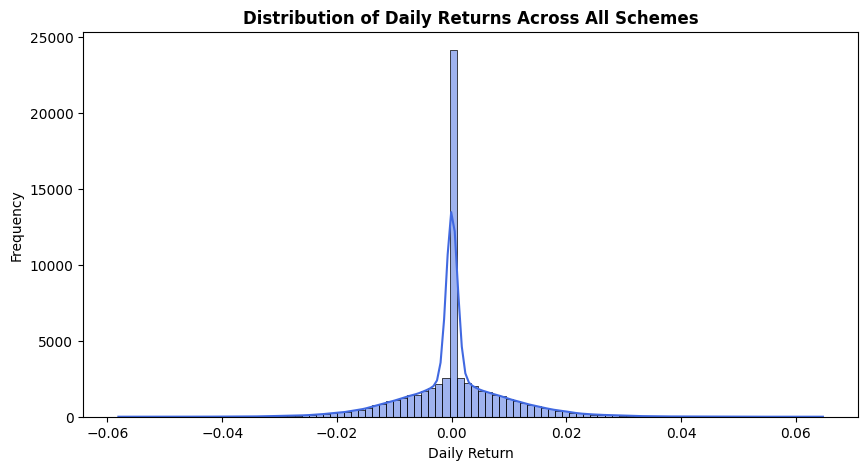

In [2]:
nav_df = nav_df.sort_values(['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Compute summary statistics
all_returns = nav_df['daily_return'].dropna()
print("Daily Returns Distribution Statistics:")
print(f"  Total return days: {len(all_returns)}")
print(f"  Mean daily return: {all_returns.mean():.6%}")
print(f"  Std Dev of daily returns: {all_returns.std():.6%}")
print(f"  Min daily return: {all_returns.min():.6%}")
print(f"  Max daily return: {all_returns.max():.6%}")
print(f"  Skewness: {all_returns.skew():.4f}")
print(f"  Kurtosis: {all_returns.kurtosis():.4f}")

# Plot distribution
plt.figure(figsize=(10, 5))
sns.histplot(all_returns, bins=100, kde=True, color='royalblue')
plt.title("Distribution of Daily Returns Across All Schemes", fontsize=12, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## 2. Compute CAGR for 1yr, 3yr, 5yr

We calculate CAGR: `CAGR = (NAV_end / NAV_start) ^ (1/n) - 1`.
The NAV history runs from 2022-01-03 to 2026-05-29 (4.40 years). The 5-year CAGR is computed over this maximum available period.

In [3]:
end_date = pd.Timestamp("2026-05-29")
start_1yr = pd.Timestamp("2025-05-29")
start_3yr = pd.Timestamp("2023-05-29")
start_5yr = pd.Timestamp("2022-01-03")

cagr_records = []
for code in nav_df['amfi_code'].unique():
    fund_nav = nav_df[nav_df['amfi_code'] == code].set_index('date')
    nav_end = fund_nav.loc[end_date, 'nav']
    nav_1yr = fund_nav.loc[start_1yr, 'nav']
    nav_3yr = fund_nav.loc[start_3yr, 'nav']
    nav_5yr = fund_nav.loc[start_5yr, 'nav']
    
    cagr_1yr = (nav_end / nav_1yr) ** (1.0 / 1.0) - 1
    cagr_3yr = (nav_end / nav_3yr) ** (1.0 / 3.0) - 1
    
    days_5yr = (end_date - start_5yr).days
    years_5yr = days_5yr / 365.25
    cagr_5yr = (nav_end / nav_5yr) ** (1.0 / years_5yr) - 1
    
    cagr_records.append({
        'amfi_code': code,
        'cagr_1yr_pct': cagr_1yr * 100,
        'cagr_3yr_pct': cagr_3yr * 100,
        'cagr_5yr_pct': cagr_5yr * 100
    })

cagr_df = pd.DataFrame(cagr_records)
cagr_df.head()

,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,100016,-2.224271,1.292649,2.637074
1,100025,3.704969,3.916390,4.458210
2,100033,53.232396,32.442459,30.123153
3,101206,47.924120,28.967695,23.538361
4,101207,-23.986032,-4.152381,7.938765


## 3. Sharpe and Sortino Ratios

- Sharpe Ratio: `(Rp - Rf) / Std(Rp) * sqrt(252)` where `Rf = 6.5%`.
- Sortino Ratio: same but denominator uses downside standard deviation (negative return days only).

In [4]:
Rf_annual = 0.065
Rf_daily = Rf_annual / 252

ratio_records = []
for code in nav_df['amfi_code'].unique():
    fund_returns = nav_df[(nav_df['amfi_code'] == code) & (nav_df['daily_return'].notna())]['daily_return']
    
    excess = fund_returns - Rf_daily
    sharpe = (excess.mean() / fund_returns.std()) * np.sqrt(252)
    
    downside_returns = fund_returns[fund_returns < 0]
    sortino = (excess.mean() / downside_returns.std()) * np.sqrt(252)
    
    ratio_records.append({
        'amfi_code': code,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'std_dev_ann_pct': fund_returns.std() * np.sqrt(252) * 100
    })

ratios_df = pd.DataFrame(ratio_records)
ratios_df.head()

,amfi_code,sharpe_ratio,sortino_ratio,std_dev_ann_pct
0,100016,-0.321019,-0.472822,12.300430
1,100025,-1.039941,-1.461220,3.304017
2,100033,0.808268,1.144216,16.029119
3,101206,0.717409,1.063909,12.332110
4,101207,0.052618,0.075668,21.812983


## 4. Alpha and Beta

We compute Alpha and Beta by running an OLS regression of daily returns against Nifty 100 returns.
- `Beta = slope`
- `Alpha = intercept * 252`

In [5]:
bench_df = bench_df.sort_values(['index_name', 'date'])
bench_df['daily_return'] = bench_df.groupby('index_name')['close_value'].pct_change()

nifty100 = bench_df[(bench_df['index_name'] == 'NIFTY100') & (bench_df['daily_return'].notna())][['date', 'daily_return']]
nifty100 = nifty100.rename(columns={'daily_return': 'bench_return'})

alpha_beta_records = []
for code in nav_df['amfi_code'].unique():
    fund_ret = nav_df[(nav_df['amfi_code'] == code) & (nav_df['daily_return'].notna())][['date', 'daily_return']]
    merged = pd.merge(fund_ret, nifty100, on='date', how='inner')
    
    slope, intercept, r_val, p_val, std_err = stats.linregress(merged['bench_return'], merged['daily_return'])
    alpha_beta_records.append({
        'amfi_code': code,
        'alpha': intercept * 252 * 100,
        'beta': slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta_records)
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,3.747581,-0.058268
1,100025,4.281792,0.001158
2,100033,27.195355,0.005104
3,101206,21.399785,0.021086
4,101207,10.897092,-0.065289


## 5. Maximum Drawdown & Date Ranges

Calculate `drawdown = NAV / running_max - 1` and find the worst peak-to-trough range.

In [6]:
dd_records = []
for code in nav_df['amfi_code'].unique():
    fund_nav = nav_df[nav_df['amfi_code'] == code].sort_values('date').reset_index(drop=True)
    nav_series = fund_nav['nav']
    date_series = fund_nav['date']
    
    running_max = nav_series.cummax()
    drawdowns = nav_series / running_max - 1
    max_dd = drawdowns.min()
    
    trough_idx = drawdowns.idxmin()
    trough_date = date_series.iloc[trough_idx]
    peak_val = running_max.iloc[trough_idx]
    
    peak_idx = nav_series.iloc[:trough_idx + 1][nav_series.iloc[:trough_idx + 1] == peak_val].index[-1]
    peak_date = date_series.iloc[peak_idx]
    
    dd_records.append({
        'amfi_code': code,
        'max_drawdown_pct': max_dd * 100,
        'drawdown_peak_date': peak_date.strftime('%Y-%m-%d'),
        'drawdown_trough_date': trough_date.strftime('%Y-%m-%d')
    })

drawdown_df = pd.DataFrame(dd_records)
drawdown_df.head()

,amfi_code,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date
0,100016,-24.734441,2022-03-30,2022-09-15
1,100025,-4.308264,2023-05-23,2023-07-28
2,100033,-16.217209,2022-03-13,2022-05-12
3,101206,-11.291596,2023-04-24,2023-07-05
4,101207,-35.446916,2024-11-21,2026-05-11


## 6. Fund Scorecard (0-100)

We build a composite ranking using normalized percentile ranks:
`Score = 30% * rank_3yr + 25% * rank_Sharpe + 20% * rank_Alpha + 15% * rank_expense (inverse) + 10% * rank_max_dd (inverse)`.

In [7]:
score_df = master_df[['amfi_code', 'scheme_name', 'expense_ratio_pct']].copy()
score_df = score_df.merge(cagr_df, on='amfi_code')
score_df = score_df.merge(ratios_df, on='amfi_code')
score_df = score_df.merge(alpha_beta_df, on='amfi_code')
score_df = score_df.merge(drawdown_df, on='amfi_code')

score_df['rank_3yr'] = score_df['cagr_3yr_pct'].rank(pct=True) * 100
score_df['rank_Sharpe'] = score_df['sharpe_ratio'].rank(pct=True) * 100
score_df['rank_Alpha'] = score_df['alpha'].rank(pct=True) * 100
score_df['rank_expense'] = score_df['expense_ratio_pct'].rank(ascending=False, pct=True) * 100
score_df['rank_max_dd'] = score_df['max_drawdown_pct'].rank(ascending=True, pct=True) * 100

score_df['score'] = (
    0.30 * score_df['rank_3yr'] +
    0.25 * score_df['rank_Sharpe'] +
    0.20 * score_df['rank_Alpha'] +
    0.15 * score_df['rank_expense'] +
    0.10 * score_df['rank_max_dd']
)
score_df['scorecard_rank'] = score_df['score'].rank(ascending=False, method='min').astype(int)
score_df = score_df.sort_values('scorecard_rank')

print("Top 5 Funds according to Scorecard:")
score_df[['scorecard_rank', 'scheme_name', 'score', 'cagr_3yr_pct', 'sharpe_ratio', 'alpha']].head(5)

Top 5 Funds according to Scorecard:


,scorecard_rank,scheme_name,score,cagr_3yr_pct,sharpe_ratio,alpha
34,1,Mirae Asset Large Cap Fund - Regular - Growth,86.250,34.000916,1.068224,26.983751
12,2,ICICI Pru Midcap Fund - Regular - Growth,82.875,31.777537,0.883256,29.263583
22,3,Kotak Flexicap Fund - Regular - Growth,82.000,29.582770,0.965561,27.330465
7,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.750,32.442459,0.808268,27.195355
11,5,ICICI Pru Bluechip Fund - Direct - Growth,79.375,32.487429,0.714682,21.194827


## 7. Benchmark Comparison Line Chart

Plot the top 5 funds normalized NAV vs Nifty 50 and Nifty 100 indices (starting at 100 on 2023-05-29).

Mirae Asset Large Cap Fund:
  TE vs Nifty 50: 17.4056%
  TE vs Nifty 100: 17.7247%
ICICI Pru Midcap Fund:
  TE vs Nifty 50: 21.6570%
  TE vs Nifty 100: 20.9539%
Kotak Flexicap Fund:
  TE vs Nifty 50: 18.8061%
  TE vs Nifty 100: 18.3595%
HDFC Mid-Cap Opportunities Fund:
  TE vs Nifty 50: 20.2192%
  TE vs Nifty 100: 20.1306%
ICICI Pru Bluechip Fund:
  TE vs Nifty 50: 17.3993%
  TE vs Nifty 100: 17.4668%


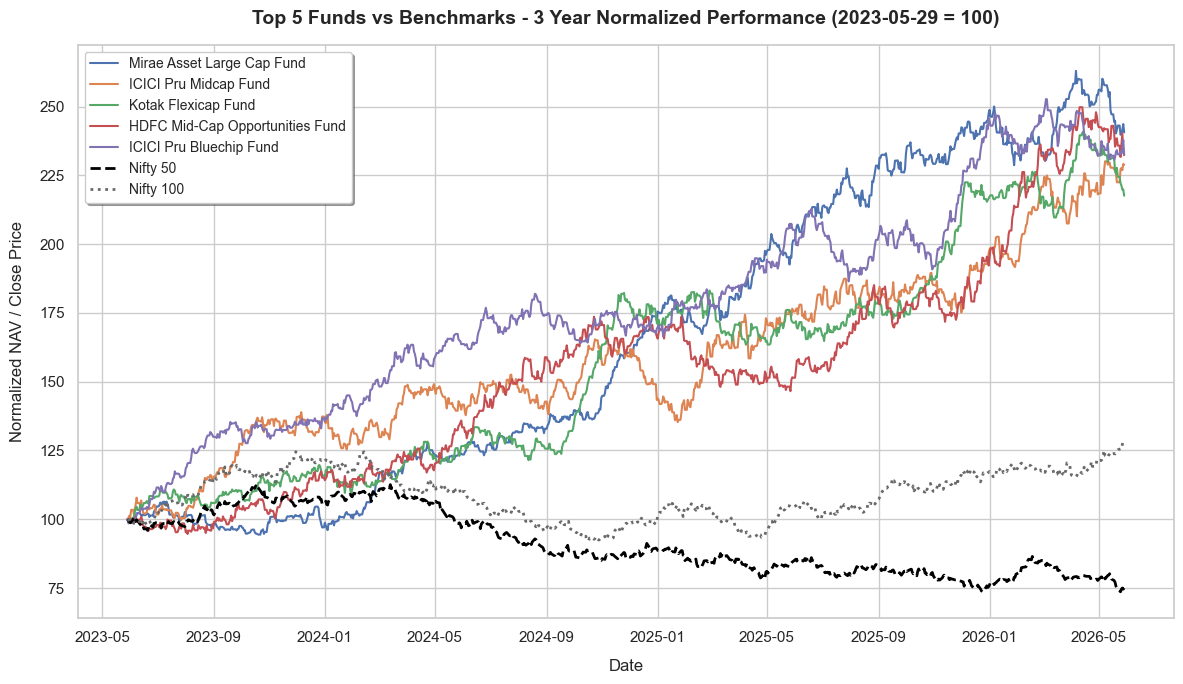

In [8]:
top_5 = score_df.head(5)
top_5_codes = top_5['amfi_code'].tolist()
top_5_names = top_5['scheme_name'].tolist()

start_date = pd.Timestamp("2023-05-29")
end_date = pd.Timestamp("2026-05-29")

nifty50_all = bench_df[(bench_df['index_name'] == 'NIFTY50') & (bench_df['date'] >= start_date) & (bench_df['date'] <= end_date)].sort_values('date')
nifty100_all = bench_df[(bench_df['index_name'] == 'NIFTY100') & (bench_df['date'] >= start_date) & (bench_df['date'] <= end_date)].sort_values('date')

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

for code, name in zip(top_5_codes, top_5_names):
    fund_data = nav_df[(nav_df['amfi_code'] == code) & (nav_df['date'] >= start_date) & (nav_df['date'] <= end_date)].sort_values('date')
    base_nav = fund_data.iloc[0]['nav']
    normalized_nav = (fund_data['nav'] / base_nav) * 100
    
    plt.plot(fund_data['date'], normalized_nav, label=name.split(" - ")[0], linewidth=1.5)
    
    fund_ret = fund_data['daily_return'].values[1:]
    n50_ret = nifty50_all['daily_return'].values[1:]
    n100_ret = nifty100_all['daily_return'].values[1:]
    
    min_len_50 = min(len(fund_ret), len(n50_ret))
    min_len_100 = min(len(fund_ret), len(n100_ret))
    
    te_n50 = np.std(fund_ret[:min_len_50] - n50_ret[:min_len_50], ddof=1) * np.sqrt(252) * 100
    te_n100 = np.std(fund_ret[:min_len_100] - n100_ret[:min_len_100], ddof=1) * np.sqrt(252) * 100
    
    print(f"{name.split(' - ')[0]}:")
    print(f"  TE vs Nifty 50: {te_n50:.4f}%")
    print(f"  TE vs Nifty 100: {te_n100:.4f}%")

n50_base = nifty50_all.iloc[0]['close_value']
normalized_n50 = (nifty50_all['close_value'] / n50_base) * 100
plt.plot(nifty50_all['date'], normalized_n50, label='Nifty 50', color='black', linestyle='--', linewidth=2)

n100_base = nifty100_all.iloc[0]['close_value']
normalized_n100 = (nifty100_all['close_value'] / n100_base) * 100
plt.plot(nifty100_all['date'], normalized_n100, label='Nifty 100', color='dimgray', linestyle=':', linewidth=2)

plt.title("Top 5 Funds vs Benchmarks - 3 Year Normalized Performance (2023-05-29 = 100)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12, labelpad=10)
plt.ylabel("Normalized NAV / Close Price", fontsize=12, labelpad=10)
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
plt.tight_layout()
plt.show()